# Coupled vs independent multi-horizon TSGAM forecasts

This notebook is a deliberately small demonstration of the forecast-mode coupling effect.

The important thing to watch is the **fit**, not only the final forecast line. Independent direct multi-horizon forecasting fits one TSGAM per horizon. Coupled mode fits the horizons together and penalizes rough horizon-to-horizon movement in matching coefficients.

In this synthetic example the target is:

- a known periodic signal;
- plus a smooth exogenous driver entering through three lags;
- plus a small amount of noise.

Because the lagged driver columns are correlated, the independent horizon fits can trade weight between lags and become jagged. With a first-order coupling penalty, coupled mode should learn lag coefficients that stay nearly constant across horizons.

In [10]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "tsgam_estimator").exists()
)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from tsgam_estimator import (
    TsgamEstimatorConfig,
    TsgamForecastConfig,
    TsgamForecastCouplingConfig,
    TsgamForecastEstimator,
    TsgamLinearConfig,
    TsgamMultiPeriodicConfig,
    TsgamSolverConfig,
)

MODEL_COLORS = {
    "true": "#111827",
    "coupled": "#2563eb",
    "independent": "#dc2626",
}
MODEL_STYLES = {
    "true": "-",
    "coupled": "-",
    "independent": "--",
}
MODEL_MARKERS = {
    "true": "o",
    "coupled": "o",
    "independent": "o",
}


## 1. Make a small synthetic problem

We use a direct multi-horizon setup with eight horizons. At forecast origin `t`, horizon 1 predicts `y[t+1]`, horizon 2 predicts `y[t+2]`, and so on.

The exogenous driver is intentionally smooth. That makes `driver[t]`, `driver[t-1]`, and `driver[t-2]` correlated, which is a useful stress test: independent horizon fits can find several nearly equivalent lag-weight combinations.

In [11]:
HORIZON = 8
SAMPLES = 504
TRAIN_FRACTION = 0.60
NOISE_SCALE = 0.08
SEED = 12
COUPLED_ROUGHNESS = 0.5

LAGS = [-2, -1, 0]
TRUE_DRIVER_WEIGHTS = {-2: 0.15, -1: 0.30, 0: 0.55}


def lagged_contribution(driver: np.ndarray) -> tuple[np.ndarray, dict[int, np.ndarray]]:
    total = np.zeros_like(driver)
    parts: dict[int, np.ndarray] = {}
    for lag, coefficient in TRUE_DRIVER_WEIGHTS.items():
        part = np.zeros_like(driver)
        if lag < 0:
            part[-lag:] = coefficient * driver[:lag]
        elif lag == 0:
            part = coefficient * driver
        else:
            part[:-lag] = coefficient * driver[lag:]
        total += part
        parts[lag] = part
    return total, parts


def make_data() -> pd.DataFrame:
    rng = np.random.default_rng(SEED)
    index = pd.date_range("2024-01-01", periods=SAMPLES, freq="1h")
    t = np.arange(SAMPLES, dtype=float)

    daily = 1.4 * np.sin(2.0 * np.pi * t / 24.0)
    daily_harmonic = 0.45 * np.cos(2.0 * np.pi * t / 12.0)
    weekly = 0.55 * np.sin(2.0 * np.pi * t / 168.0 - 0.5)
    periodic = daily + daily_harmonic + weekly

    position = np.linspace(0.0, 1.0, SAMPLES)
    raw_driver = (
        1.1 * (position - 0.5)
        + 0.8 * np.exp(-0.5 * ((position - 0.42) / 0.12) ** 2)
        - 0.6 / (1.0 + np.exp(-(position - 0.72) / 0.05))
        + rng.normal(scale=0.02, size=SAMPLES)
    )
    driver = (raw_driver - raw_driver.mean()) / raw_driver.std()
    driver_total, driver_parts = lagged_contribution(driver)

    signal = periodic + driver_total
    observed = signal + rng.normal(scale=NOISE_SCALE, size=SAMPLES)

    return pd.DataFrame(
        {
            "observed": observed,
            "signal": signal,
            "periodic": periodic,
            "daily": daily,
            "daily harmonic": daily_harmonic,
            "weekly": weekly,
            "driver": driver,
            "driver contribution": driver_total,
            **{f"driver lag {lag}": part for lag, part in driver_parts.items()},
        },
        index=index,
    )


data = make_data()
train_stop = int(len(data) * TRAIN_FRACTION)
train_time = data.index[train_stop]
print(f"training rows: {train_stop:,} / {len(data):,}")
print(f"forecast horizon: {HORIZON}")
print(f"true lag weights: {TRUE_DRIVER_WEIGHTS}")


training rows: 302 / 504
forecast horizon: 8
true lag weights: {-2: 0.15, -1: 0.3, 0: 0.55}


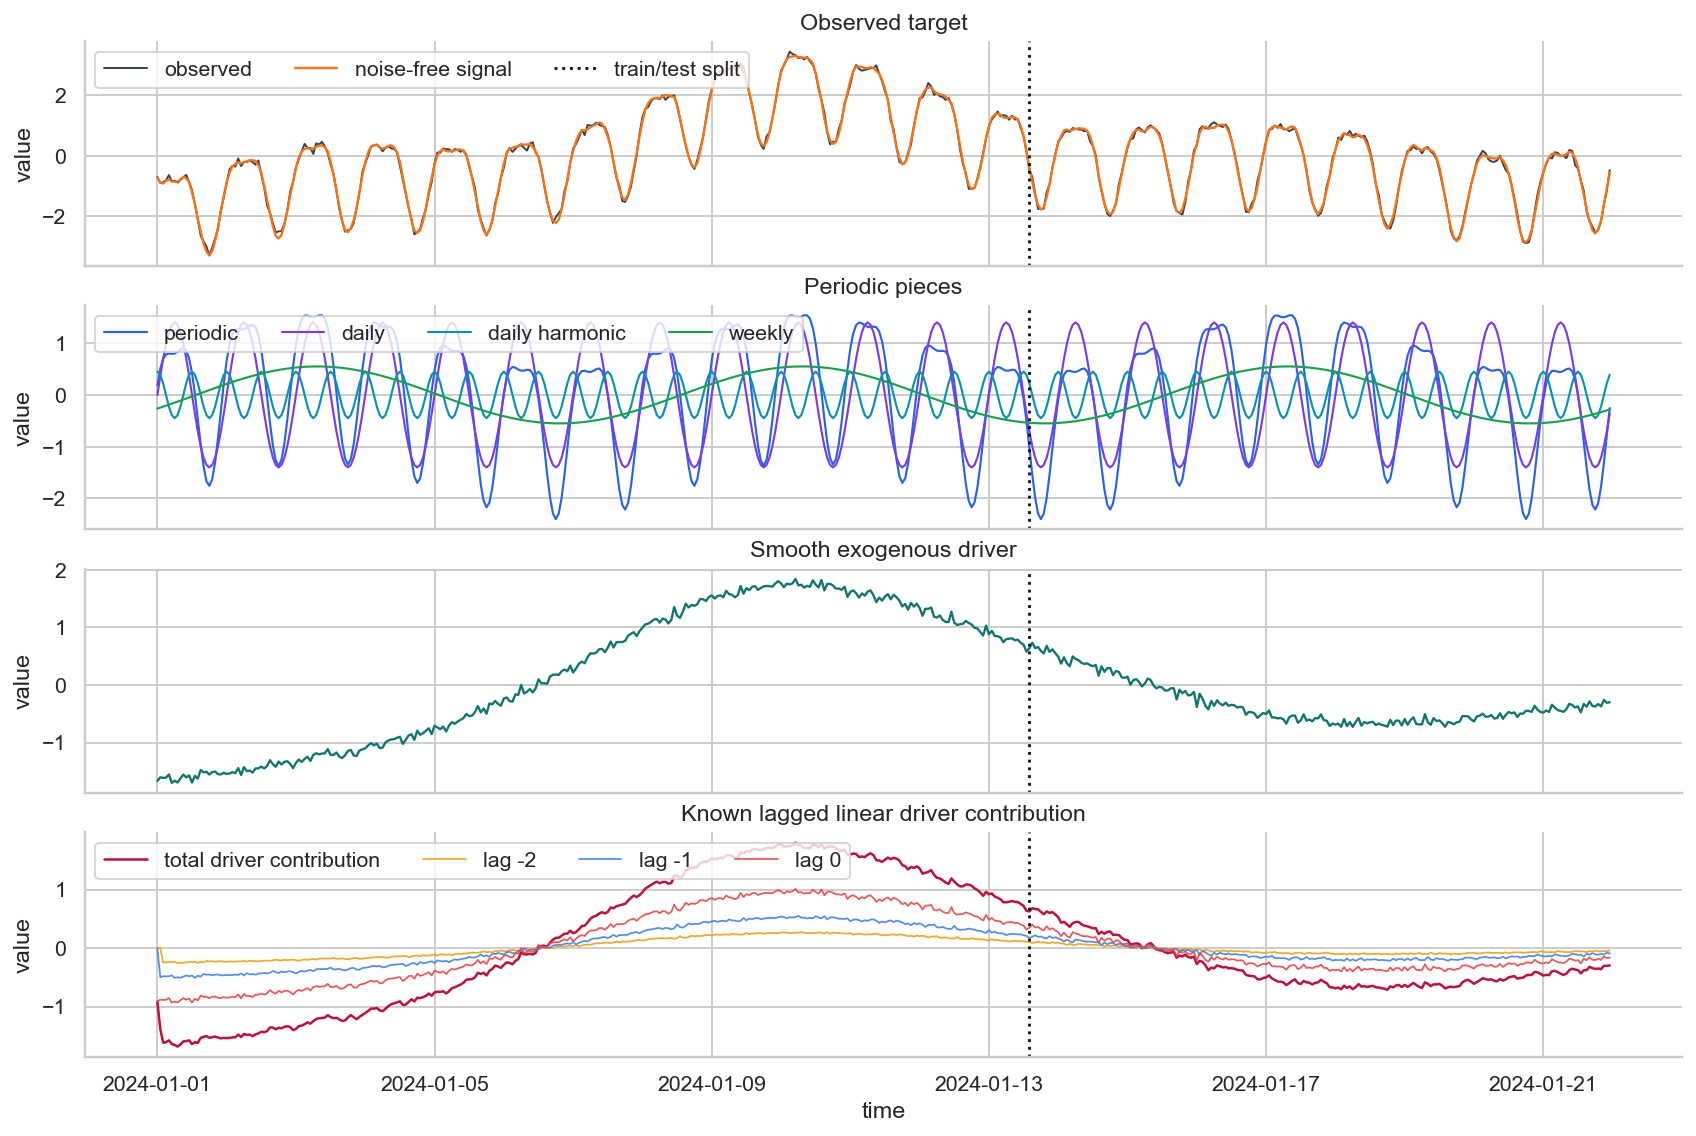

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True, constrained_layout=True)

axes[0].plot(data.index, data["observed"], color="#334155", lw=1.0, label="observed")
axes[0].plot(data.index, data["signal"], color="#f97316", lw=1.2, label="noise-free signal")
axes[0].axvline(train_time, color="#111827", ls=":", lw=1.5, label="train/test split")
axes[0].set_title("Observed target")
axes[0].legend(loc="upper left", ncols=3)

for column, color in [("periodic", "#2563eb"), ("daily", "#7c3aed"), ("daily harmonic", "#0891b2"), ("weekly", "#16a34a")]:
    axes[1].plot(data.index, data[column], lw=1.1, label=column, color=color)
axes[1].axvline(train_time, color="#111827", ls=":", lw=1.5)
axes[1].set_title("Periodic pieces")
axes[1].legend(loc="upper left", ncols=4)

axes[2].plot(data.index, data["driver"], color="#0f766e", lw=1.2)
axes[2].axvline(train_time, color="#111827", ls=":", lw=1.5)
axes[2].set_title("Smooth exogenous driver")

axes[3].plot(data.index, data["driver contribution"], color="#be123c", lw=1.3, label="total driver contribution")
for lag, color in [(-2, "#f59e0b"), (-1, "#3b82f6"), (0, "#ef4444")]:
    axes[3].plot(data.index, data[f"driver lag {lag}"], lw=0.9, alpha=0.9, label=f"lag {lag}", color=color)
axes[3].axvline(train_time, color="#111827", ls=":", lw=1.5)
axes[3].set_title("Known lagged linear driver contribution")
axes[3].legend(loc="upper left", ncols=4)
axes[3].set_xlabel("time")

for ax in axes:
    ax.set_ylabel("value")

plt.show()


## 2. Fit independent and coupled forecast models

Both models use the same single-horizon TSGAM ingredients: target-time periodic bases and the same three exogenous lags.

The only difference is forecast mode:

- **Independent:** fit eight separate horizon problems.
- **Coupled:** fit one joint problem and penalize first differences of matching coefficients across horizon.

In [13]:
def base_config() -> TsgamEstimatorConfig:
    return TsgamEstimatorConfig(
        multi_periodic_config=TsgamMultiPeriodicConfig(
            num_harmonics=[4, 2],
            periods=[24, 168],
            reg_weight=1.0e-8,
        ),
        exog_config=[
            TsgamLinearConfig(
                lags=LAGS,
                reg_weight=1.0e-10,
                diff_reg_weight=1.0e-10,
            )
        ],
        solver_config=TsgamSolverConfig(solver="CLARABEL", verbose=False),
    )

x_all = data[["driver"]]
y_all = data["observed"].to_numpy()
x_train = x_all.iloc[:train_stop]
y_train = y_all[:train_stop]
x_eval = x_all.iloc[train_stop:-HORIZON]

independent = TsgamForecastEstimator(
    TsgamForecastConfig(
        horizon=HORIZON,
        base_config=base_config(),
        mode="independent",
    )
).fit(x_train, y_train)

coupled = TsgamForecastEstimator(
    TsgamForecastConfig(
        horizon=HORIZON,
        base_config=base_config(),
        mode="coupled",
        coupling_config=TsgamForecastCouplingConfig(
            roughness_weight=COUPLED_ROUGHNESS,
            roughness_order=1,
        ),
    )
).fit(x_train, y_train)

independent_pred = independent.predict(x_eval)
coupled_pred = coupled.predict(x_eval)
actual = pd.DataFrame(
    {
        f"horizon_{h}": data["observed"].shift(-h).loc[x_eval.index]
        for h in range(1, HORIZON + 1)
    },
    index=x_eval.index,
)

print("fitted independent and coupled forecast models")


fitted independent and coupled forecast models


## 3. The coupling effect in the fit

This is the main figure. Each panel is one lagged driver coefficient.

The black line is the true coefficient used to generate the data. The red dashed line is the independent direct multi-horizon fit. The blue line is the coupled fit.

The coupled path should be flatter because the coupled objective now penalizes horizon-to-horizon coefficient changes directly.

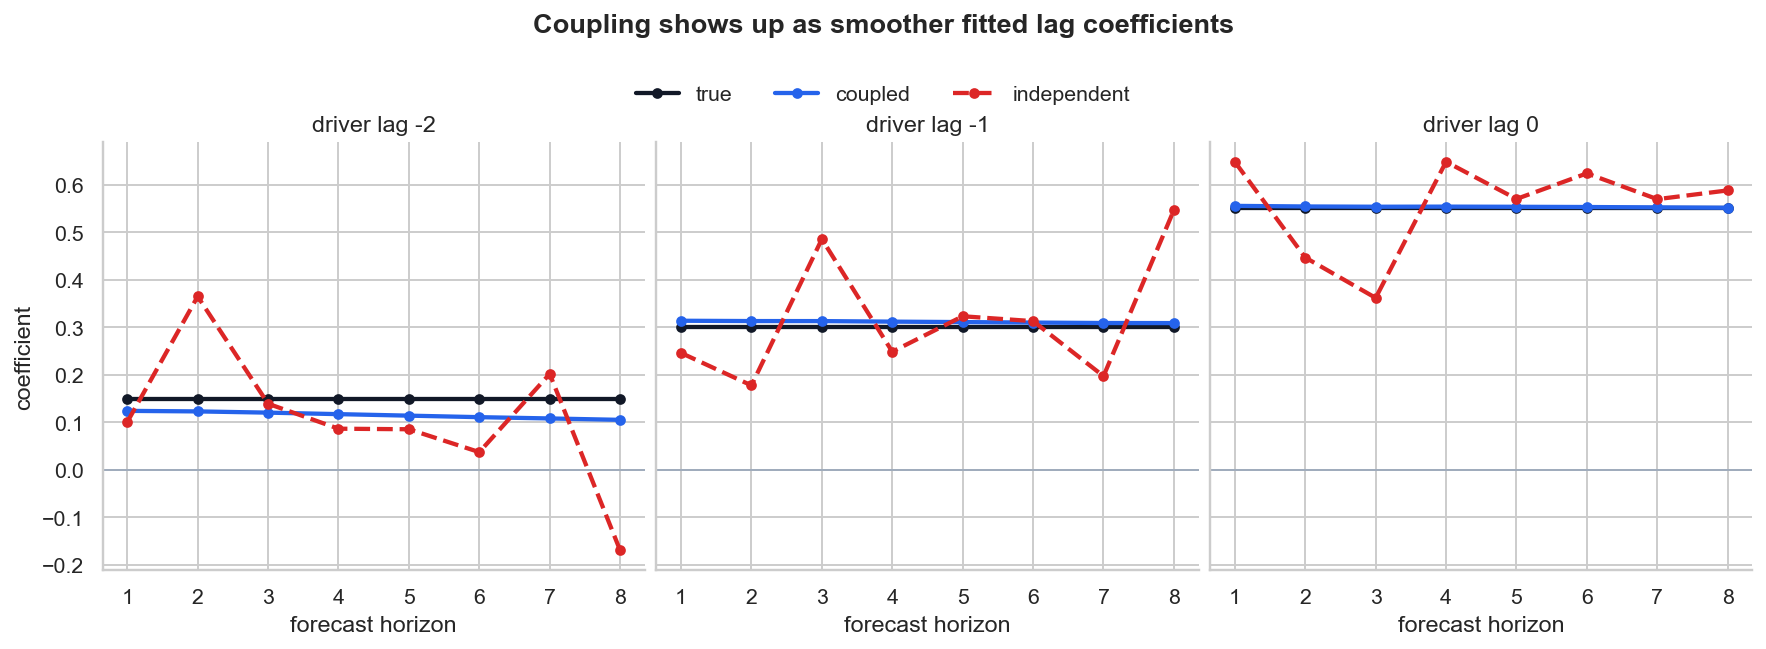

In [14]:
def coefficient_frame() -> pd.DataFrame:
    rows = []
    for horizon in range(1, HORIZON + 1):
        coupled_horizon_ix = coupled.horizons_.index(horizon)
        independent_child = independent.forecast_estimators_[horizon]
        for lag_index, lag in enumerate(LAGS):
            rows.append(
                {
                    "horizon": horizon,
                    "lag": lag,
                    "model": "true",
                    "coefficient": TRUE_DRIVER_WEIGHTS[lag],
                }
            )
            rows.append(
                {
                    "horizon": horizon,
                    "lag": lag,
                    "model": "independent",
                    "coefficient": float(
                        independent_child.variables_["exog_coef_0"].value[0, lag_index]
                    ),
                }
            )
            rows.append(
                {
                    "horizon": horizon,
                    "lag": lag,
                    "model": "coupled",
                    "coefficient": float(
                        coupled.variables_["exog_coef_0"][coupled_horizon_ix].value[0, lag_index]
                    ),
                }
            )
    return pd.DataFrame(rows)

coef = coefficient_frame()

fig, axes = plt.subplots(1, len(LAGS), figsize=(12.5, 3.8), sharey=True, constrained_layout=True)
for ax, lag in zip(axes, LAGS):
    panel = coef[coef["lag"] == lag]
    for model in ["true", "coupled", "independent"]:
        model_data = panel[panel["model"] == model]
        ax.plot(
            model_data["horizon"],
            model_data["coefficient"],
            label=model,
            color=MODEL_COLORS[model],
            linestyle=MODEL_STYLES[model],
            marker=MODEL_MARKERS[model],
            lw=2.2,
            ms=4.5,
        )
    ax.set_title(f"driver lag {lag}")
    ax.set_xlabel("forecast horizon")
    ax.set_xticks(range(1, HORIZON + 1))
    ax.axhline(0.0, color="#94a3b8", lw=0.8)

axes[0].set_ylabel("coefficient")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=3, frameon=False, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Coupling shows up as smoother fitted lag coefficients", y=1.18, fontsize=14, fontweight="bold")
plt.show()


In [15]:
def total_first_difference_roughness(coef_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model in ["true", "coupled", "independent"]:
        model_total = 0.0
        for lag in LAGS:
            values = (
                coef_frame[(coef_frame["model"] == model) & (coef_frame["lag"] == lag)]
                .sort_values("horizon")["coefficient"]
                .to_numpy()
            )
            model_total += float(np.sum(np.diff(values) ** 2))
        rows.append({"model": model, "total coefficient first-difference roughness": model_total})
    return pd.DataFrame(rows)

roughness_summary = total_first_difference_roughness(coef)
roughness_summary


,model,total coefficient first-difference roughness
0,true,0.000000
1,coupled,0.000062
2,independent,0.728811


## 4. Forecasts can look similar even when the fit differs

On this clean synthetic problem, both models often forecast well. That is exactly why the coefficient figure matters: the coupled model can make similar predictions while using a smoother horizon-wise fit.

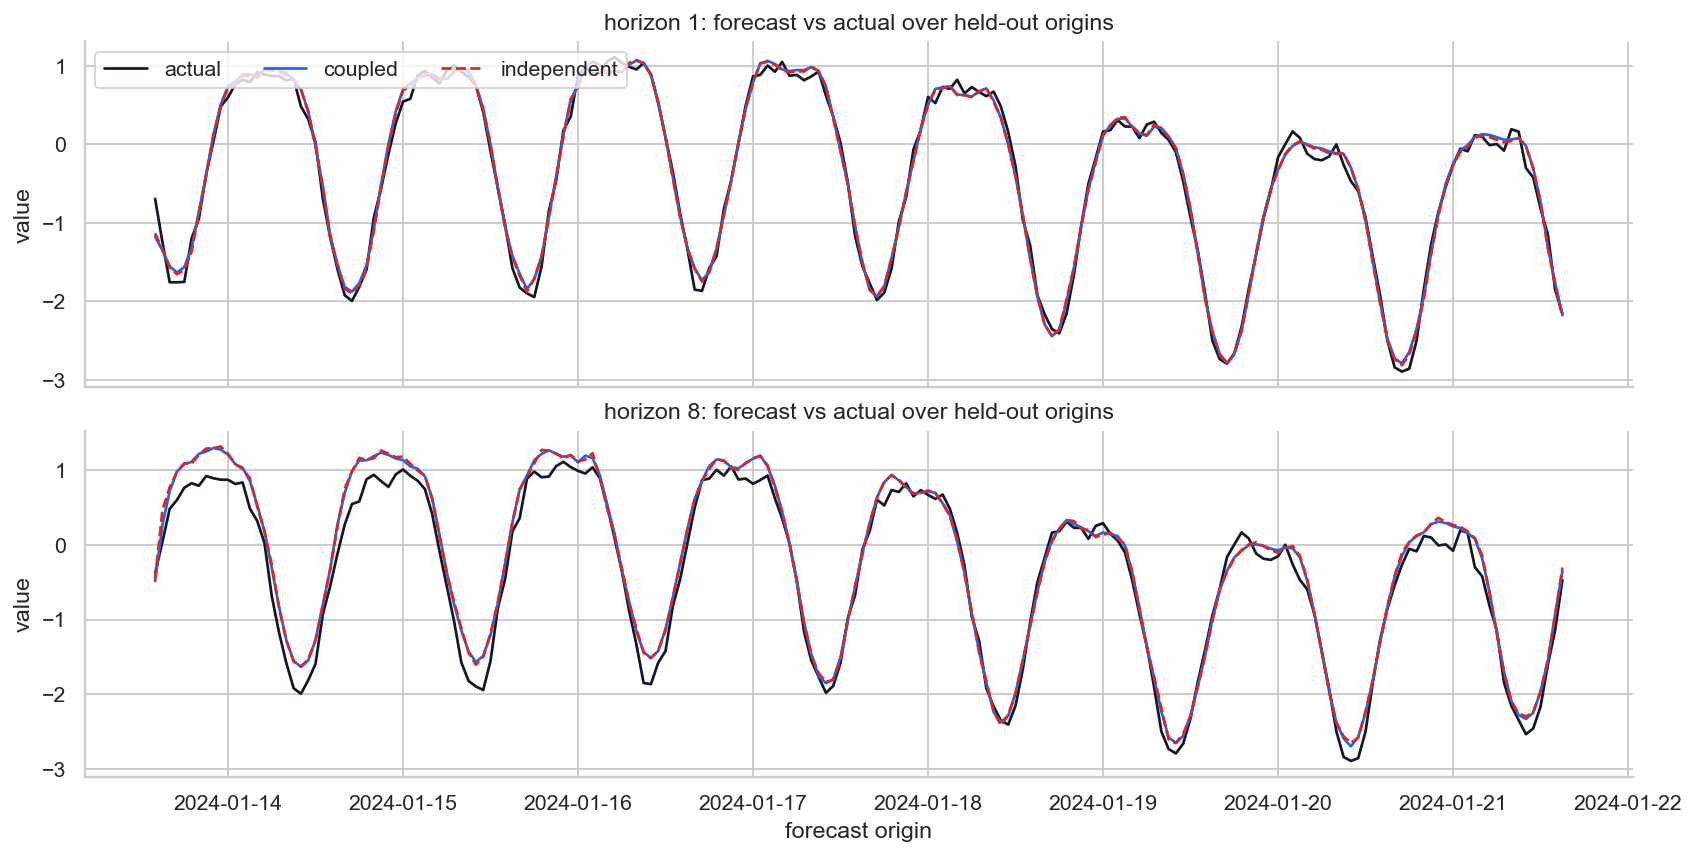

In [16]:
def forecast_long_frame(horizon: int) -> pd.DataFrame:
    column = f"horizon_{horizon}"
    return pd.concat(
        [
            actual[[column]].rename(columns={column: "value"}).assign(model="actual"),
            independent_pred[[column]].rename(columns={column: "value"}).assign(model="independent"),
            coupled_pred[[column]].rename(columns={column: "value"}).assign(model="coupled"),
        ]
    ).reset_index(names="origin_time")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
for ax, horizon in zip(axes, [1, HORIZON]):
    plot_data = forecast_long_frame(horizon)
    for model, color, linestyle in [
        ("actual", "#111827", "-"),
        ("coupled", MODEL_COLORS["coupled"], "-"),
        ("independent", MODEL_COLORS["independent"], "--"),
    ]:
        model_data = plot_data[plot_data["model"] == model]
        ax.plot(model_data["origin_time"], model_data["value"], label=model, color=color, linestyle=linestyle, lw=1.4)
    ax.set_title(f"horizon {horizon}: forecast vs actual over held-out origins")
    ax.set_ylabel("value")
axes[-1].set_xlabel("forecast origin")
axes[0].legend(loc="upper left", ncols=3)
plt.show()


In [17]:
metric_rows = []
for model, prediction in [("independent", independent_pred), ("coupled", coupled_pred)]:
    for column in actual.columns:
        error = prediction[column] - actual[column]
        metric_rows.append(
            {
                "model": model,
                "horizon": int(column.split("_")[1]),
                "rmse": float(np.sqrt(np.mean(error**2))),
                "mae": float(np.mean(np.abs(error))),
            }
        )
metrics = pd.DataFrame(metric_rows)
metrics.pivot(index="horizon", columns="model", values="rmse").round(4)


model,coupled,independent
horizon,,
1,0.1090,0.1046
2,0.1156,0.1182
3,0.1231,0.1262
4,0.1377,0.1366
5,0.1553,0.1555
6,0.1755,0.1755
7,0.1928,0.1986
8,0.2087,0.2165


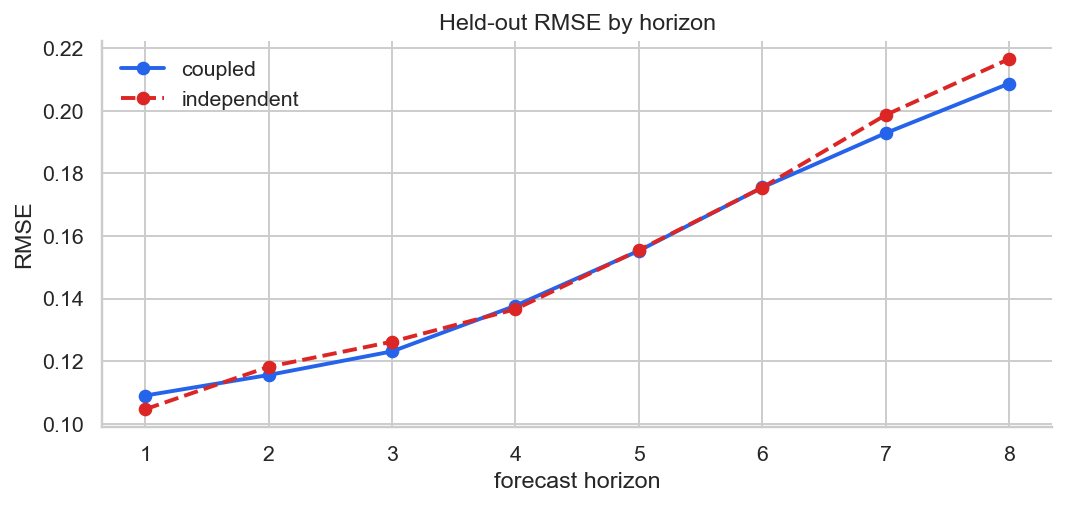

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 3.5), constrained_layout=True)
for model in ["coupled", "independent"]:
    model_metrics = metrics[metrics["model"] == model]
    ax.plot(
        model_metrics["horizon"],
        model_metrics["rmse"],
        marker="o",
        lw=2,
        color=MODEL_COLORS[model],
        linestyle=MODEL_STYLES[model],
        label=model,
    )
ax.set_title("Held-out RMSE by horizon")
ax.set_xlabel("forecast horizon")
ax.set_ylabel("RMSE")
ax.set_xticks(range(1, HORIZON + 1))
ax.legend(frameon=False)
plt.show()


## Takeaway

The coupled model is not guaranteed to draw a dramatically different forecast line on an easy problem. Its visible effect is that matching coefficients across horizons move together instead of each horizon independently chasing small-sample variation.

That is the practical story this notebook is designed to show: **coupling changes the fitted horizon structure**.